# Importing Libraries and Loading Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Unemployment in India.csv')

# Display the first 5 rows of the DataFrame
display(df.head(5))

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# Data Cleaning and Preprocessing

In [2]:
# Clean column names by stripping leading/trailing spaces
df.columns = df.columns.str.strip()

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Drop rows with any missing values, as the number of missing rows is relatively small (28 out of 768)
df.dropna(inplace=True)

# Verify data types and non-null counts after cleaning
df.info()

# Display the first few rows of the cleaned DataFrame
display(df.head(5))

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


# Line Plot

## Unemployment Rate Trend Analysis

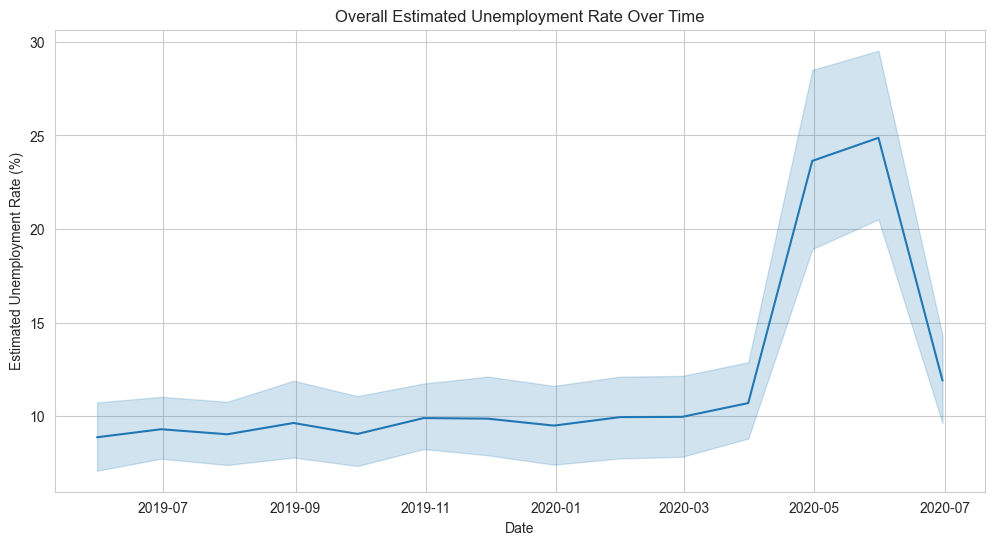

In [3]:

# Set plot style
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))

# Plot overall estimated unemployment rate over time
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=df)
plt.title('Overall Estimated Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.show()

# Bar Plot

## Estimated Unemployment Rate by Region

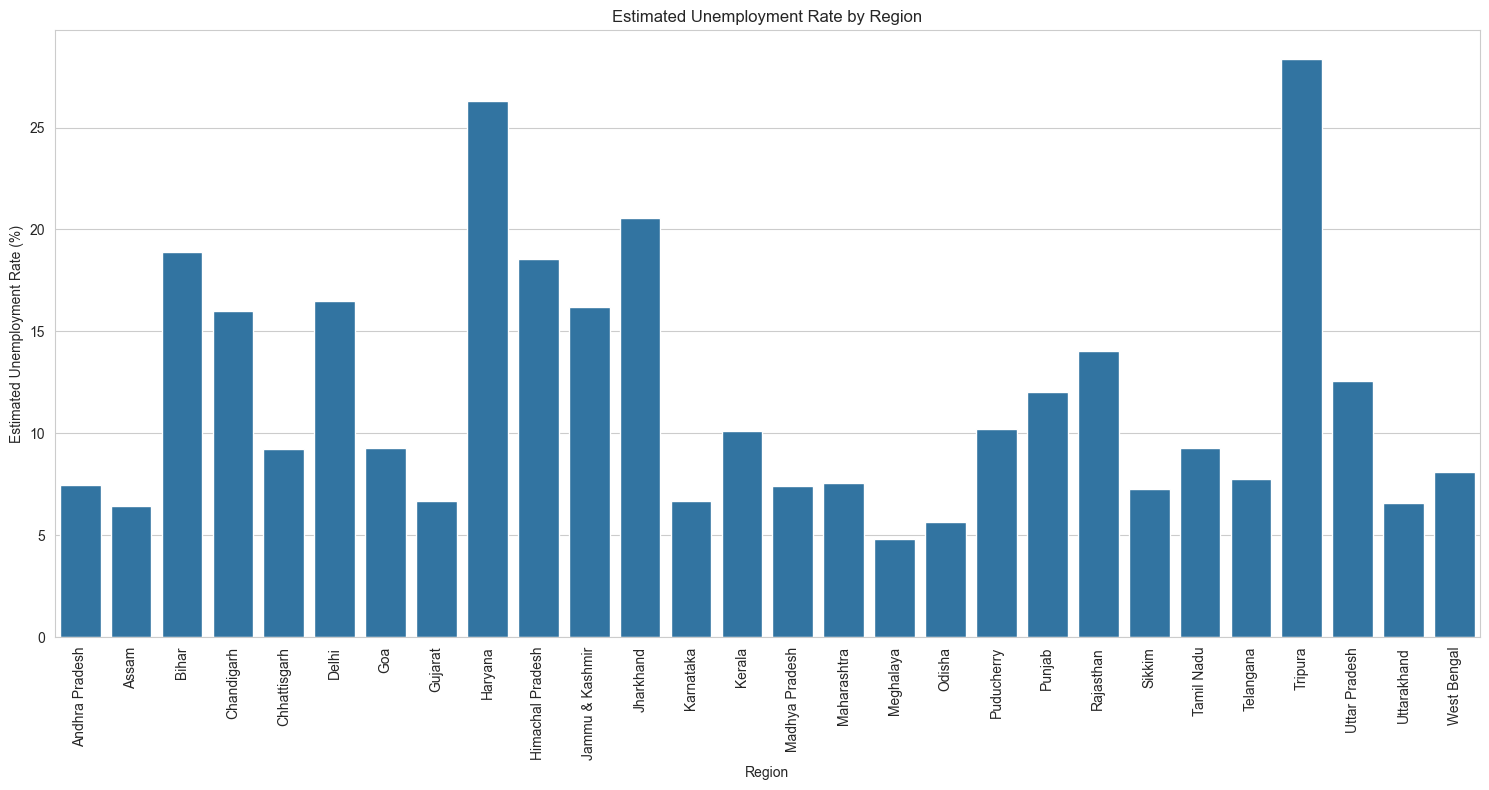

In [4]:
plt.figure(figsize=(15, 8))
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index()
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=region_avg)
plt.title('Estimated Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Bar Plot of Estimated Unemployment Rate by Area

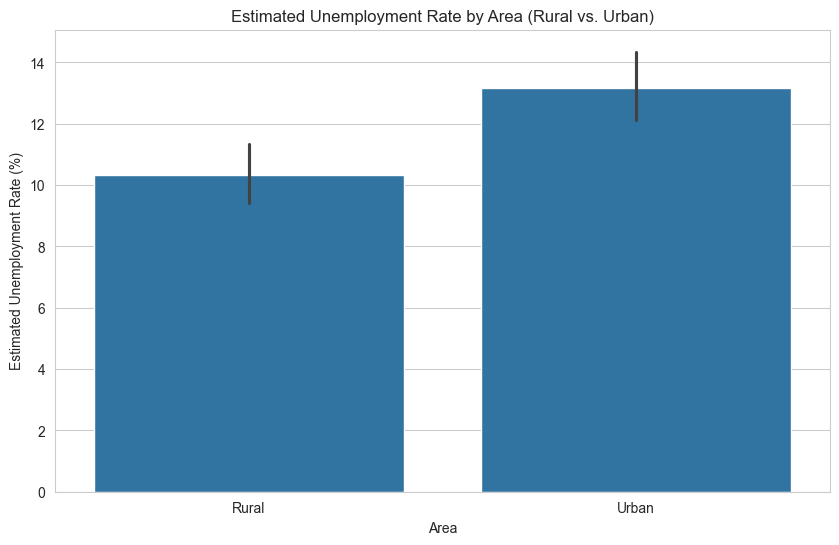

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)
plt.title('Estimated Unemployment Rate by Area (Rural vs. Urban)')
plt.xlabel('Area')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.show()

# Bar Plot of Monthly Unemployment Trend in India

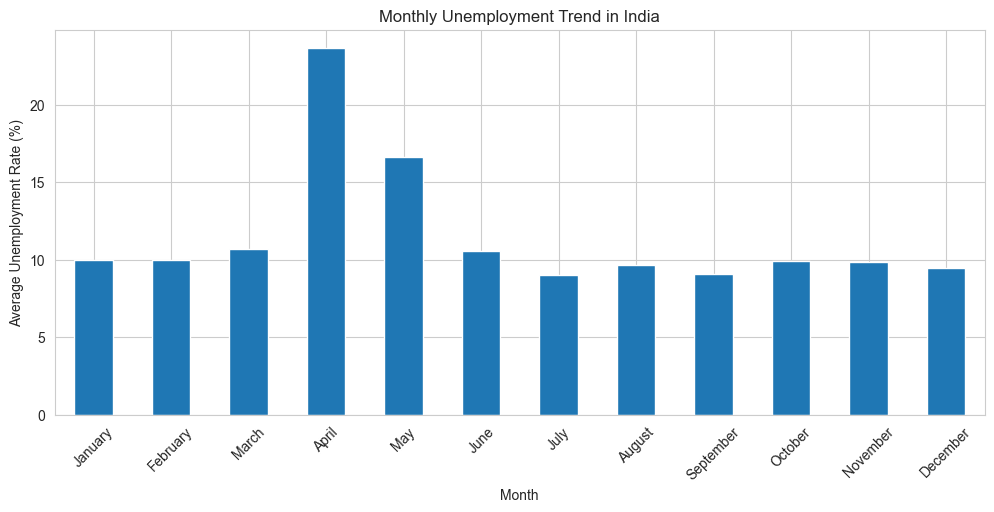

In [6]:
# Extract month name
df['Month'] = df['Date'].dt.month_name()

# Calculate monthly average unemployment
monthly_trend = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

monthly_trend = monthly_trend.reindex(months_order)

# Plot
plt.figure(figsize=(12,5))
monthly_trend.plot(kind='bar')

plt.title('Monthly Unemployment Trend in India')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.show()

# Line Plot of Estimated Unemployment Rate During COVID-19 Period

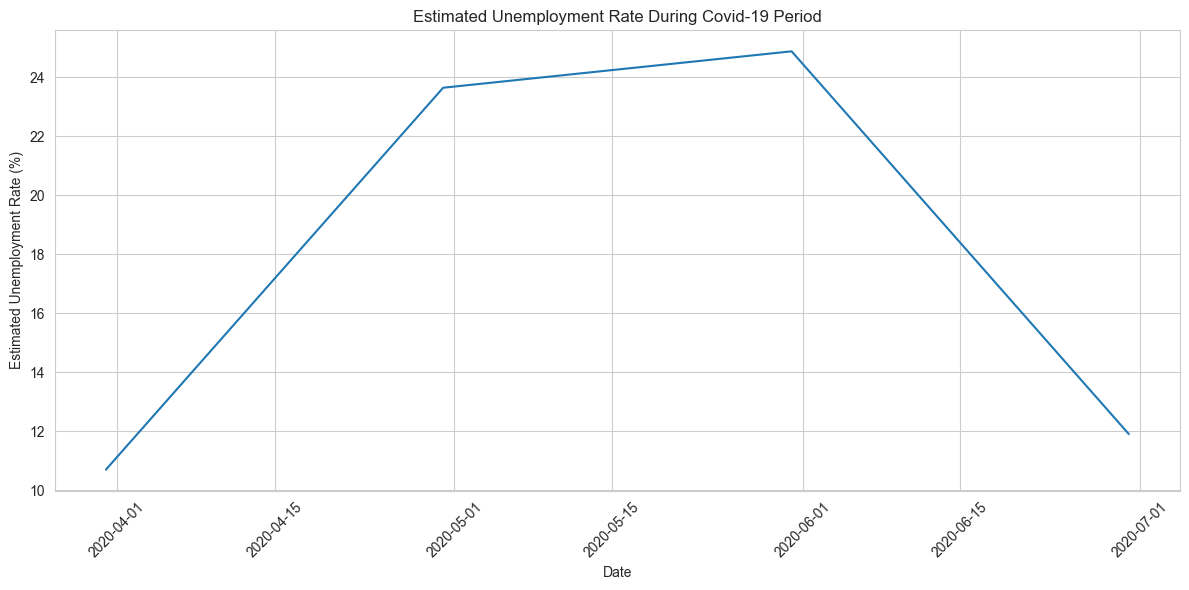

In [7]:
# Identify the approximate start of the Covid-19 pandemic in India (March 2020)
covid_start_date = pd.to_datetime('2020-03-01')

# Create a new DataFrame for pre and post-covid analysis
df_covid = df[df['Date'] >= covid_start_date]

# Aggregate data to get monthly average unemployment rate during COVID
unemployment_monthly_covid = df_covid.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=unemployment_monthly_covid)
plt.title('Estimated Unemployment Rate During Covid-19 Period')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Bar Plot of Top 10 Regions with Highest Unemployment

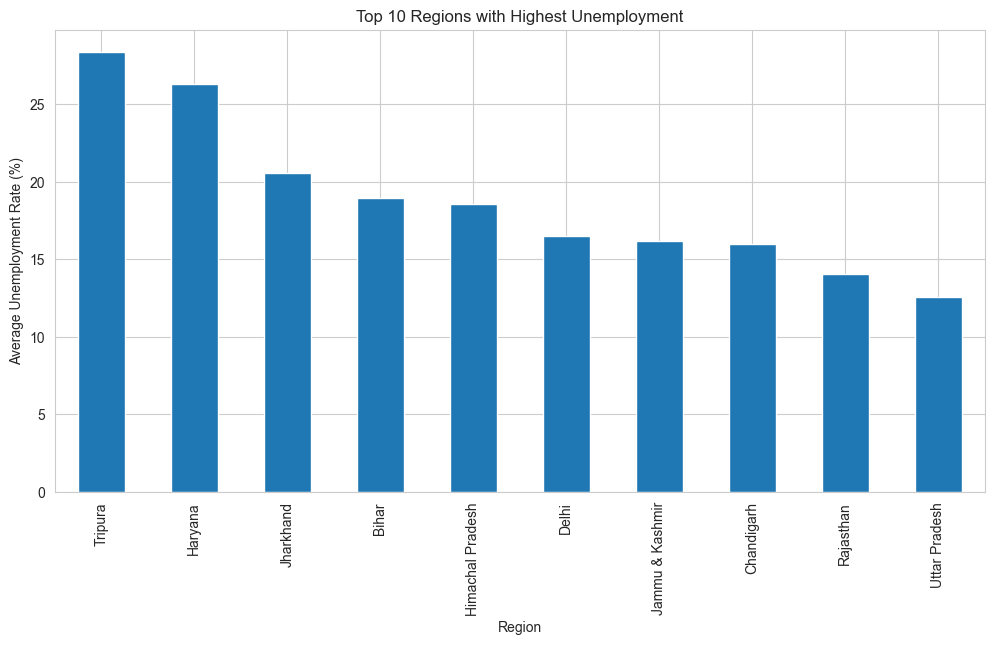

In [8]:
state_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_unemployment.head(10).plot(kind='bar')

plt.title('Top 10 Regions with Highest Unemployment')
plt.ylabel('Average Unemployment Rate (%)')

plt.show()

# Correlation Heatmap Between Variables

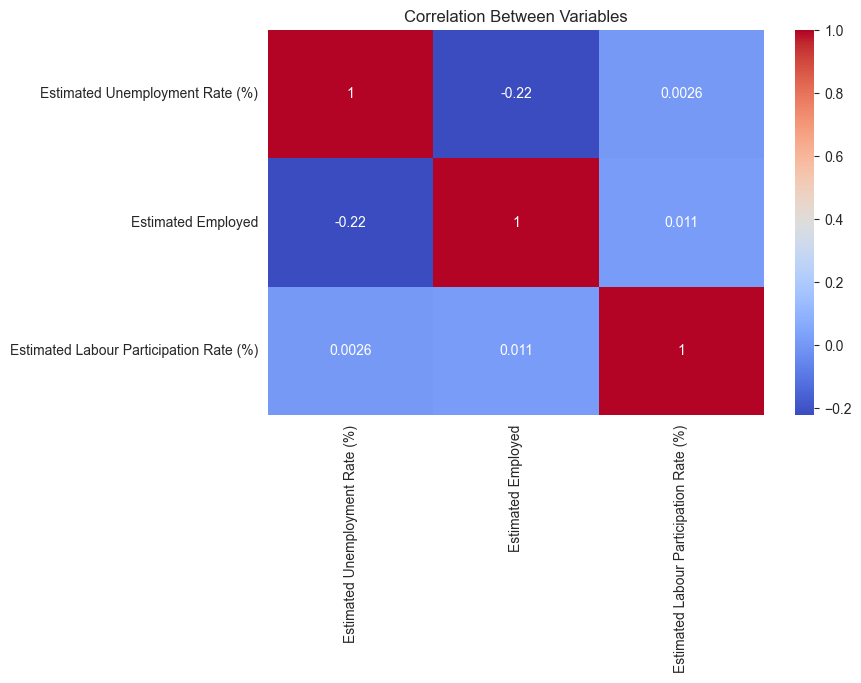

In [9]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Variables')

plt.show()

## Insights and Policy Recommendations

1. Key Insights

1. The unemployment rate increased sharply during the Covid-19 pandemic,
especially during lockdown periods.

2. Urban regions experienced higher unemployment compared to rural regions
because many industries and businesses were closed.

3. Seasonal analysis showed fluctuations in unemployment across different months,
indicating unstable employment opportunities.

4. Some states consistently recorded higher unemployment rates,
suggesting regional economic imbalance.

5. Labour participation rates also changed during the pandemic,
showing uncertainty in the job market.

2. Policy Recommendations

1. The government should strengthen employment programs during economic crises.

2. Skill development and vocational training programs can help reduce unemployment.

3. Financial support should be provided to small businesses during pandemics
to protect jobs.

4. Rural employment opportunities should be expanded to reduce migration pressure.

5. Digital infrastructure and remote work opportunities should be improved
to maintain employment during emergencies.